<a href="https://colab.research.google.com/github/mjtemdark/cov19ml/blob/main/Proyecto_Final_MachineLearning_26092026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Proyecto Final COVID

Curso: Machine Learning

Integrantes:

 - Manuel Laura Jaramillo
 - Aydee Carolina Zapana Caillahua
 - Absalon Chambilla Condori

Docente: Miguel Romilio Aceituno Rojo


## Librerías y configuración

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

warnings.filterwarnings("ignore", category=FutureWarning)

## 0. CONFIGURACIÓN

In [ ]:
import kagglehub,os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_10545264f6b54e0bd995ca4fd9829565"

path = kagglehub.dataset_download("manuellaura/covid-puno")

In [ ]:
CARPETA_SALIDA = Path("salidas_preprocesamiento")
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

# I. PREPROCESAMIENTO DE DATOS

## 1. CARGA DE DATOS

In [ ]:
df = pd.read_csv(
    path+"/covid.csv",
    low_memory=False,
    encoding="utf-8"
)

print("1. CARGA DE DATOS")
print("_" * 70)
print(f"Filas iniciales   : {df.shape[0]:,}")
print(f"Columnas iniciales: {df.shape[1]:,}")

df_original = df.copy()
df_clean = df.copy()

## 2. EDA INICIAL



2. ANÁLISIS EXPLORATORIO INICIAL
______________________________________________________________________

Variables con mayor porcentaje de nulos:
                         tipo  nulos  porcentaje_nulos  valores_unicos
otro_hos              float64  95315            100.00               0
secuenciamiento       float64  95315            100.00               0
ciudad_3               object  95169             99.85              68
entrada                object  94975             99.64              10
contacto_otro          object  94952             99.62             221
servicio_otro          object  94633             99.28              53
resultado2             object  94544             99.19               2
prueba2                object  94518             99.16               3
muestra2               object  94518             99.16               4
ciudad_2               object  94458             99.10             176
entorno_otro           object  94428             99.07             339


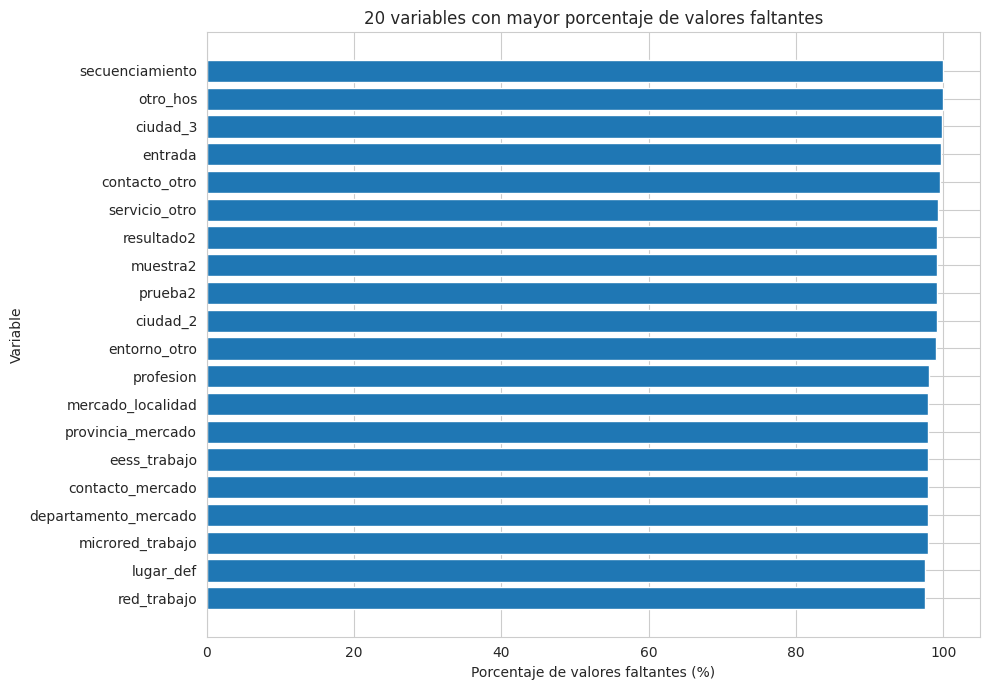

______________________________________________________________________


In [ ]:
print("\n")
print("2. ANÁLISIS EXPLORATORIO INICIAL")
print("_" * 70)

resumen_inicial = pd.DataFrame({
    "tipo": df_clean.dtypes.astype(str),
    "nulos": df_clean.isna().sum(),
    "porcentaje_nulos": (df_clean.isna().mean() * 100).round(2),
    "valores_unicos": df_clean.nunique(dropna=True)
}).sort_values("porcentaje_nulos", ascending=False)

resumen_inicial.to_csv(
    CARPETA_SALIDA / "01_resumen_inicial.csv",
    encoding="utf-8-sig"
)

print("\nVariables con mayor porcentaje de nulos:")
print(resumen_inicial.head(20))


# Gráfico de porcentaje de nulos
top_nulos = resumen_inicial.head(20).sort_values("porcentaje_nulos")

plt.figure(figsize=(10, 7))
plt.barh(top_nulos.index, top_nulos["porcentaje_nulos"])
plt.xlabel("Porcentaje de valores faltantes (%)")
plt.ylabel("Variable")
plt.title("20 variables con mayor porcentaje de valores faltantes")
plt.tight_layout()
plt.savefig(
    CARPETA_SALIDA / "01_top20_valores_faltantes.png",
    dpi=150,
    bbox_inches="tight"
)
print("_" * 70)
plt.show()
print("_" * 70)

## 3. DUPLICADOS

In [ ]:
print("\n")
print("3. DUPLICADOS")
print("_" * 70)

n_duplicados = int(df_clean.duplicated().sum())
print(f"Duplicados exactos encontrados: {n_duplicados}")

if n_duplicados > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Duplicados después de la revisión: {df_clean.duplicated().sum()}")



3. DUPLICADOS
______________________________________________________________________
Duplicados exactos encontrados: 0
Duplicados después de la revisión: 0


## 4. NORMALIZACIÓN DE TEXTOS

In [ ]:
print("\n")
print("4. NORMALIZACIÓN DE TEXTOS")
print("_" * 70)

cols_texto = df_clean.select_dtypes(
    include=["object", "string"]
).columns.tolist()

for col in cols_texto:
    s = df_clean[col].astype("string")
    s = (
        s.str.strip()
         .str.replace(r"\s+", " ", regex=True)
         .str.upper()
    )
    s = s.replace({"": pd.NA})
    df_clean[col] = s

print(f"Columnas de texto normalizadas: {len(cols_texto)}")


# 4.1 Normalización de tipos de prueba rápida

def normalizar_prueba_rapida(serie):
    s = serie.astype("string")
    s = (
        s.str.replace("&NBSP;", " ", regex=False)
         .str.replace(r"[\xa0\u200b\u2007\u202f\s]+", " ", regex=True)
         .str.replace(r"[^\w\sÁÉÍÓÚÑ]", "", regex=True)
         .str.strip()
         .str.upper()
    )

    variantes_rapida = {
        "RAPIDO", "RPUEBA RAPIDA", "PRUEBA RAÁPIDA", "RPIDA",
        "RÀPIDA", "RAPIDA", "RÁPIDA", "RAPIDAR",
        "PRUEBA RAPIDA", "PRUEBA RAPIDA COVID 19",
        "PRUEBA RAPIDA COVID19", "TEST RAPIDO PARA COVID 19",
        "PRUEVA RAPIDA", "PRUEBA RRAPIDA", "PR COVID 19", "R", "PR"
    }

    variantes_serologica = {
        "SEROLOGIA", "SEROLOGICA", "SEROLOGICO", "SERELOGICA",
        "SEROLOGÍA", "PRUEBA SEROLOGICA", "SEROÓGICA", "S",
        "CEROLOGICA", "SEROLÓGICO", "SEROLIGICA"
    }

    variantes_sangre = {
        "SANGRE TOTAL", "RAPIDA SANGRE TOTAL",
        "RÁPIDA SANGRE TOTAL", "SANGRE",
        "MUESTRA DE SANGRE", "SANGREZ TOTAL"
    }

    s = s.replace(list(variantes_rapida), "PRUEBA RÁPIDA")
    s = s.replace(list(variantes_serologica), "SEROLÓGICA")
    s = s.replace(
        list(variantes_sangre),
        "PRUEBA RÁPIDA SANGRE TOTAL"
    )

    return s


for col in ["prueba_rap", "prueba_rap1"]:
    if col in df_clean.columns:
        df_clean[col] = normalizar_prueba_rapida(df_clean[col])



4. NORMALIZACIÓN DE TEXTOS
______________________________________________________________________
Columnas de texto normalizadas: 108


## 5. CONVERSIÓN DE FECHAS

In [ ]:
print("\n")
print("5. CONVERSIÓN DE FECHAS")
print("_" * 70)

datecols = [
    c for c in df_clean.columns
    if c.lower().startswith("fecha_")
]

marcadores_fecha_invalida = [
    "00-00-0000",
    "00/00/0000",
    "0000-00-00",
    "0",
    "00000000"
]

for col in datecols:
    s = df_clean[col].astype("string").str.strip()
    s = s.replace(marcadores_fecha_invalida, pd.NA)

    # errors="coerce":
    # fechas inválidas/desconocidas -> NaT
    df_clean[col] = pd.to_datetime(
        s,
        dayfirst=True,
        errors="coerce"
    )

print(f"Columnas convertidas a datetime: {len(datecols)}")



5. CONVERSIÓN DE FECHAS
______________________________________________________________________
Columnas convertidas a datetime: 17


## 6. COLUMNAS COMPLETAMENTE VACÍAS

In [ ]:
print("\n")
print("6. COLUMNAS COMPLETAMENTE VACÍAS")
print("_" * 70)

cols_100_nulos = [
    c for c in df_clean.columns
    if df_clean[c].isna().all()
]

print("Columnas 100% nulas:", cols_100_nulos)

# Solo estas se eliminan automáticamente.
df_clean = df_clean.drop(columns=cols_100_nulos)

porcentaje_nulos = (
    df_clean.isna().mean() * 100
).sort_values(ascending=False)

candidatas_muy_incompletas = porcentaje_nulos[
    porcentaje_nulos >= 95
]

candidatas_muy_incompletas.to_csv(
    CARPETA_SALIDA / "02_columnas_mayor_igual_95_nulos.csv",
    header=["porcentaje_nulos"],
    encoding="utf-8-sig"
)


print("\nColumnas con >=95% de nulos:")
print("Eliminar columnas muy incompletas (completarlas produciría datos inventados).")
print(candidatas_muy_incompletas.round(2))
print(f"\nTotal de columnas a eliminar: {len(candidatas_muy_incompletas)}")

df_clean = df_clean.drop(columns=candidatas_muy_incompletas.index)
print(f"Dimensiones tras la eliminación: {df_clean.shape}")



6. COLUMNAS COMPLETAMENTE VACÍAS
______________________________________________________________________
Columnas 100% nulas: ['otro_hos', 'secuenciamiento']

Columnas con >=95% de nulos:
Eliminar columnas muy incompletas (completarlas produciría datos inventados).
ciudad_3                99.85
entrada                 99.64
contacto_otro           99.62
servicio_otro           99.28
resultado2              99.19
fecha_res2              99.19
muestra2                99.16
prueba2                 99.16
fecha_mue2              99.16
ciudad_2                99.10
entorno_otro            99.07
profesion               98.06
mercado_localidad       97.96
eess_trabajo            97.90
departamento_mercado    97.90
provincia_mercado       97.90
contacto_mercado        97.90
microred_trabajo        97.87
lugar_def               97.53
red_trabajo             97.49
fecha_def               97.47
diresa_trabajo          97.47
servicio                97.28
diagnostico_ing         97.14
departamento_

## 7. VARIABLE OBJETIVO: CLASIFICACION



7. VARIABLE OBJETIVO: CLASIFICACION
______________________________________________________________________

Distribución antes de eliminar etiquetas faltantes:
clasificacion
CONFIRMADO    51293
DESCARTADO    34325
SOSPECHOSO     9611
PROBABLE         82
<NA>              4
Name: count, dtype: Int64

Nulos en clasificacion: 4

Distribución final de la variable objetivo:
               casos  porcentaje
clasificacion                   
CONFIRMADO     51293       53.82
DESCARTADO     34325       36.01
SOSPECHOSO      9611       10.08
PROBABLE          82        0.09
______________________________________________________________________


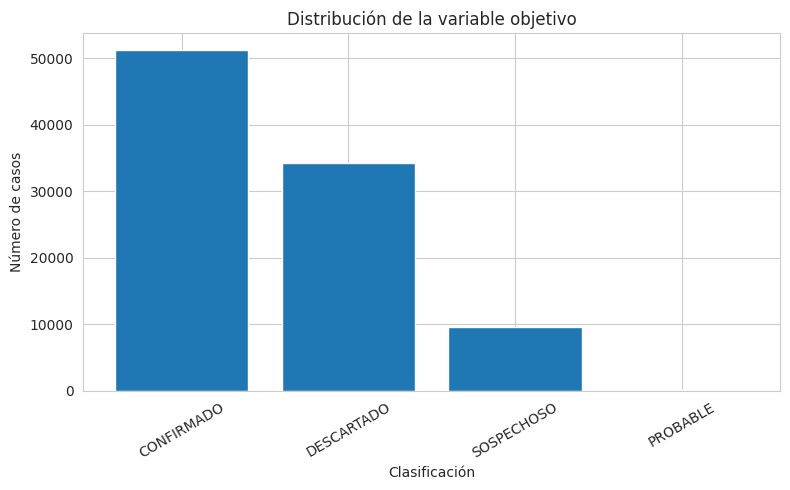

In [ ]:
print("\n")
print("7. VARIABLE OBJETIVO: CLASIFICACION")
print("_" * 70)

target = "clasificacion"

if target not in df_clean.columns:
    raise KeyError(
        f"No se encontró la variable objetivo '{target}'."
    )

print("\nDistribución antes de eliminar etiquetas faltantes:")
print(df_clean[target].value_counts(dropna=False))

n_target_null = int(df_clean[target].isna().sum())
print(f"\nNulos en {target}: {n_target_null}")

# No se imputa la variable objetivo.
df_clean = (
    df_clean
    .dropna(subset=[target])
    .reset_index(drop=True)
)

balance_clases = (
    df_clean[target]
    .value_counts()
    .rename("casos")
    .to_frame()
)

balance_clases["porcentaje"] = (
    balance_clases["casos"]
    / len(df_clean)
    * 100
).round(2)

balance_clases.to_csv(
    CARPETA_SALIDA / "03_distribucion_clasificacion.csv",
    encoding="utf-8-sig"
)

print("\nDistribución final de la variable objetivo:")
print(balance_clases)

# Gráfico de clases
plt.figure(figsize=(8, 5))
plt.bar(
    balance_clases.index.astype(str),
    balance_clases["casos"]
)
plt.xlabel("Clasificación")
plt.ylabel("Número de casos")
plt.title("Distribución de la variable objetivo")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(
    CARPETA_SALIDA / "03_distribucion_clasificacion.png",
    dpi=150,
    bbox_inches="tight"
)


print("_" * 70)
plt.show()

## 8. TRATAMIENTO DE FALTANTES SEGÚN SIGNIFICADO

In [ ]:
print("\n")
print("8. TRATAMIENTO DE FALTANTES")
print("_" * 70)

# 8.1 Asintomático
if "asintomatico" in df_clean.columns:
    print("\n'asintomatico' antes:")
    print(df_clean["asintomatico"].value_counts(dropna=False))

    # Considerar Nulo como no registrados
    df_clean["asintomatico"] = (
        df_clean["asintomatico"]
        .fillna("NO")
    )

    print("\n'asintomatico' después:")
    print(df_clean["asintomatico"].value_counts(dropna=False))


# 8.2 Categóricas administrativas/demográficas
categoricas_no_registrado = [
    "microred", "establecimiento", "institucion", "punto",
    "nacionalidad", "pais_nacionalidad", "migrante",
    "pais_origen", "pais_residencia",
    "departamento_residencia", "provincia_residencia",
    "residencia", "ubigeo", "etnia",
    "departamento_infeccion", "provincia_infeccion",
    "distrito_infeccion", "ubigeo_infeccion",
    "eess", "seguro",
    "pais_1", "pais_2", "pais_3",
    "ciudad_1", "ciudad_2", "ciudad_3",
    "contacto_pais", "departamento_contacto",
    "provincia_contacto", "contacto_ubigeo",
    "contacto_localidad", "mercado_pais",
    "otra_ocupacion", "profesion",
    "otros_sintomas", "otros_signos",
    "otros_comorbilidad"
]

for col in categoricas_no_registrado:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .fillna("NO REGISTRADO")
        )


# 8.3 Pruebas, muestras y resultados
cols_pruebas_texto = [
    "muestra", "prueba", "resultado",
    "muestra1", "prueba1", "resultado1",
    "muestra2", "prueba2", "resultado2",
    "muestra_rap", "prueba_rap", "resultado_rap",
    "muestra_rap1", "prueba_rap1", "resultado_rap1"
]

for col in cols_pruebas_texto:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .fillna("SIN REGISTRO")
        )



8. TRATAMIENTO DE FALTANTES
______________________________________________________________________

'asintomatico' antes:
asintomatico
<NA>    56341
SI      38970
Name: count, dtype: Int64

'asintomatico' después:
asintomatico
NO    56341
SI    38970
Name: count, dtype: Int64


## 9. VARIABLES BINARIAS

In [ ]:
print("\n")
print("9. VARIABLES BINARIAS")
print("_" * 70)

cols_binarias_numericas = []

for col in df_clean.select_dtypes(include=["number"]).columns:
    valores = set(
        df_clean[col]
        .dropna()
        .unique()
        .tolist()
    )

    if valores and valores.issubset({0, 1}):
        cols_binarias_numericas.append(col)

print(
    f"Variables binarias numéricas detectadas: "
    f"{len(cols_binarias_numericas)}"
)
print(cols_binarias_numericas)
# IMPORTANTE:


# Rellenar nulos con 0 en las variables binarias

df_clean[cols_binarias_numericas] = (
    df_clean[cols_binarias_numericas].fillna(0)
)




9. VARIABLES BINARIAS
______________________________________________________________________
Variables binarias numéricas detectadas: 60
['convulsion_hos', 'disnea_hos', 'coma_hos', 'auscultacion_hos', 'radiografia_hos', 'ecografia_hos', 'tomografia_hos', 'rmn_hos', 'fiebre', 'malestar', 'tos', 'garganta', 'congestion', 'respiratoria', 'diarrea', 'nauseas', 'cefalea', 'irritabilidad', 'muscular', 'abdominal', 'pecho', 'articulaciones', 'anosmia', 'ageusia', 'oido', 'exudado', 'conjuntival', 'convulsion', 'coma', 'disnea', 'auscultacion', 'rxpulmonar', 'ecografia', 'tomografia', 'rmn', 'embarazo', 'postparto', 'cardiovascular', 'diabetes', 'hepatica', 'neurologica', 'inmunodeficiencia', 'renal', 'hepatico', 'pulmonar', 'cancer', 'obesidad', 'tbc', 'asma', 'contacto_salud', 'contacto_familiar', 'contacto_trabajo', 'contacto_desconocido', 'entorno_salud', 'entorno_familiar', 'entorno_trabajo', 'casa_reposo', 'centro_penitenciario', 'albergue', 'entorno_desconocido']


## 10. VARIABLES NUMÉRICAS Y UNIDADES

In [ ]:
print("\n")
print("10. NORMALIZACIÓN DE VARIABLES NUMÉRICAS")
print("_" * 70)

# 10.1 Peso: unidad final = kg

if "peso" in df_clean.columns:
    df_clean["peso"] = pd.to_numeric(
        df_clean["peso"],
        errors="coerce"
    )

    # El dataset mezcla valores en kg y aparentemente en gramos.
    # Un peso >300 kg no es plausible para este contexto,
    # por lo que valores >300 se interpretan como gramos
    # y se convierten a kg.
    mask_peso_gramos = (
        df_clean["peso"].notna()
        & (df_clean["peso"] > 300)
    )

    df_clean.loc[
        mask_peso_gramos,
        "peso"
    ] = (
        df_clean.loc[
            mask_peso_gramos,
            "peso"
        ] / 1000
    )

    # Después de unificar unidades, se invalidan valores
    # físicamente imposibles o extremadamente improbables.
    df_clean.loc[
        (df_clean["peso"] <= 0)
        | (df_clean["peso"] > 300),
        "peso"
    ] = np.nan


# 10.2 Talla: unidad final = metros

if "talla" in df_clean.columns:
    df_clean["talla"] = pd.to_numeric(
        df_clean["talla"],
        errors="coerce"
    )

    # El dataset mezcla metros y centímetros.
    # Valores >3 se interpretan como centímetros.
    mask_talla_cm = (
        df_clean["talla"].notna()
        & (df_clean["talla"] > 3)
        & (df_clean["talla"] <= 250)
    )

    df_clean.loc[
        mask_talla_cm,
        "talla"
    ] = (
        df_clean.loc[
            mask_talla_cm,
            "talla"
        ] / 100
    )

    # Rango amplio que permite niños y adultos.
    df_clean.loc[
        (df_clean["talla"] < 0.30)
        | (df_clean["talla"] > 2.50),
        "talla"
    ] = np.nan


# 10.3 Temperatura

if "temperatura" in df_clean.columns:
    df_clean["temperatura"] = pd.to_numeric(
        df_clean["temperatura"],
        errors="coerce"
    )

    df_clean.loc[
        (df_clean["temperatura"] < 30)
        | (df_clean["temperatura"] > 45),
        "temperatura"
    ] = np.nan



# 10.4 Imputar (promedio a peso y talla)

colptall=['peso','talla']

promedios = df_clean[colptall].mean()
df_clean[colptall] = df_clean[colptall].fillna(promedios)



10. NORMALIZACIÓN DE VARIABLES NUMÉRICAS
______________________________________________________________________


## 11. EDAD EN UNA UNIDAD COMÚN

In [ ]:
print("\n")
print("11. CONVERSIÓN DE EDAD A AÑOS")
print("_" * 70)

if {"edad", "tipo_edad"}.issubset(df_clean.columns):
    unidad = (
        df_clean["tipo_edad"]
        .astype("string")
        .str.upper()
        .str.strip()
    )

    edad_num = pd.to_numeric(
        df_clean["edad"],
        errors="coerce"
    )

    es_anios = unidad.isin(
        ["A", "AÑO", "AÑOS", "ANIO", "ANIOS"]
    )

    es_meses = unidad.isin(
        ["M", "MES", "MESES"]
    )

    es_dias = unidad.isin(
        ["D", "DIA", "DÍA", "DIAS", "DÍAS"]
    )

    df_clean["edad_anios"] = np.nan

    df_clean.loc[
        es_anios,
        "edad_anios"
    ] = edad_num[es_anios]

    df_clean.loc[
        es_meses,
        "edad_anios"
    ] = edad_num[es_meses] / 12

    df_clean.loc[
        es_dias,
        "edad_anios"
    ] = edad_num[es_dias] / 365.25

    # Valores imposibles.
    df_clean.loc[
        (df_clean["edad_anios"] < 0)
        | (df_clean["edad_anios"] > 120),
        "edad_anios"
    ] = np.nan

    no_reconocidas = unidad[
        ~(es_anios | es_meses | es_dias)
        & unidad.notna()
    ].unique()

    print(
        "Unidades de edad no reconocidas:",
        no_reconocidas
    )



11. CONVERSIÓN DE EDAD A AÑOS
______________________________________________________________________
Unidades de edad no reconocidas: <StringArray>
[]
Length: 0, dtype: string


## 12. EDA DE VARIABLES CONTINUAS Y OUTLIERS



12. OUTLIERS - MÉTODO IQR
______________________________________________________________________
edad_anios: 187 valores fuera de 1.5*IQR (se revisan, no se eliminan automáticamente)
______________________________________________________________________


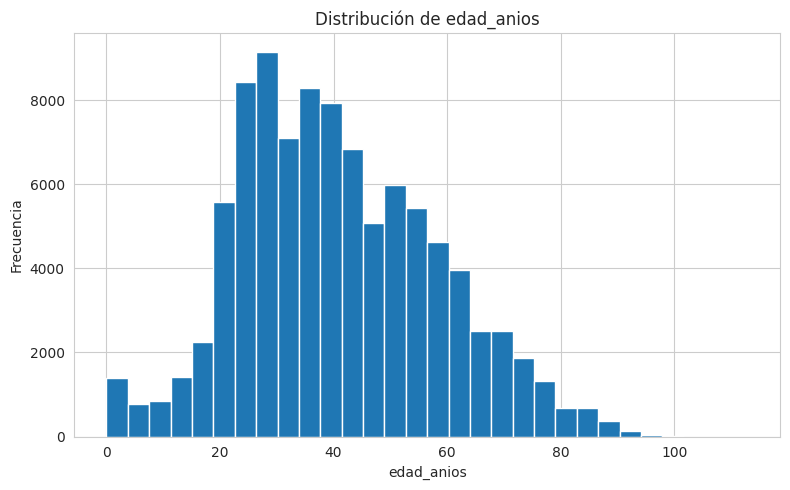

______________________________________________________________________
______________________________________________________________________


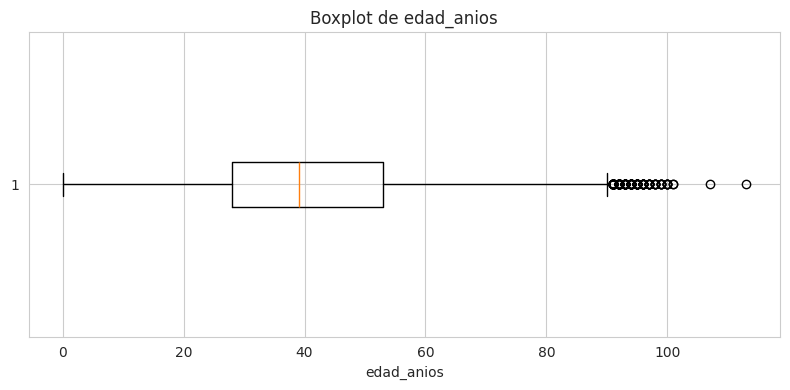

______________________________________________________________________
peso: 8901 valores fuera de 1.5*IQR (se revisan, no se eliminan automáticamente)
______________________________________________________________________


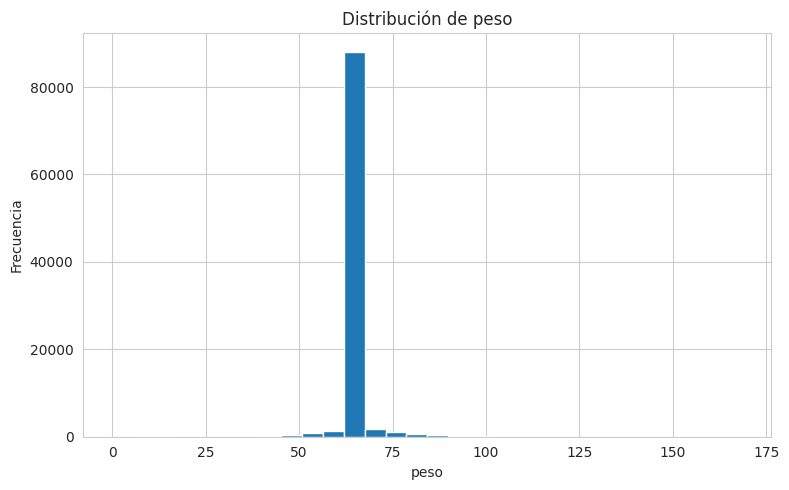

______________________________________________________________________
______________________________________________________________________


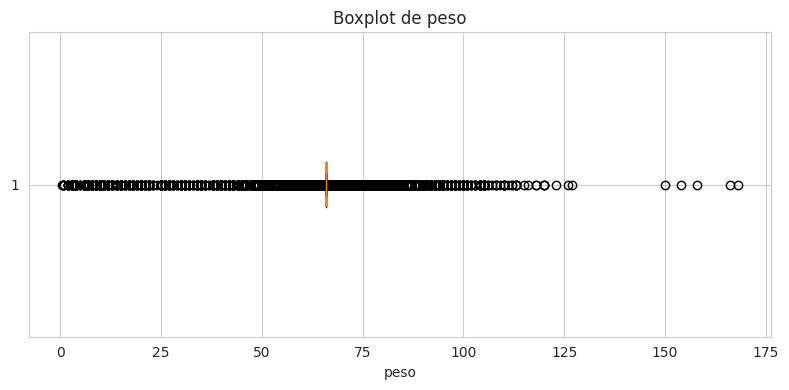

______________________________________________________________________
talla: 8842 valores fuera de 1.5*IQR (se revisan, no se eliminan automáticamente)
______________________________________________________________________


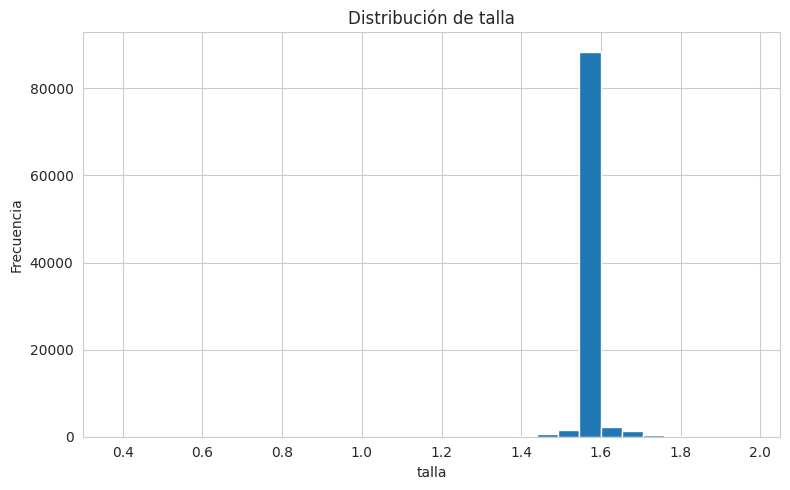

______________________________________________________________________
______________________________________________________________________


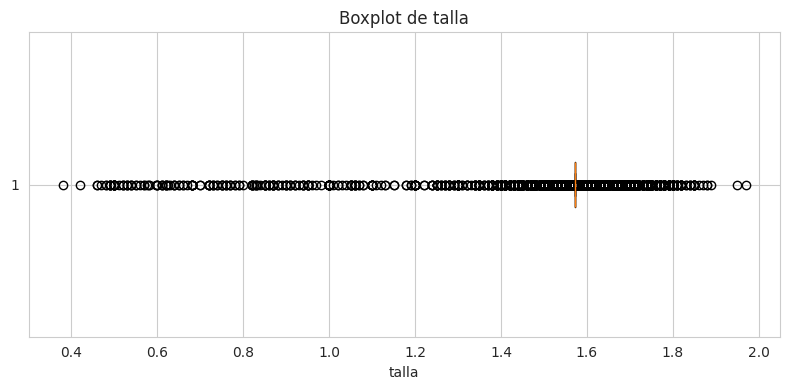

______________________________________________________________________
temperatura: 263 valores fuera de 1.5*IQR (se revisan, no se eliminan automáticamente)
______________________________________________________________________


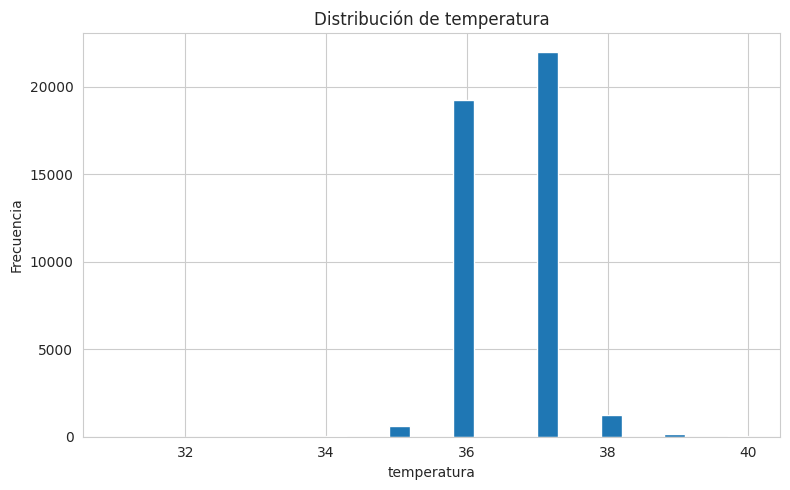

______________________________________________________________________
______________________________________________________________________


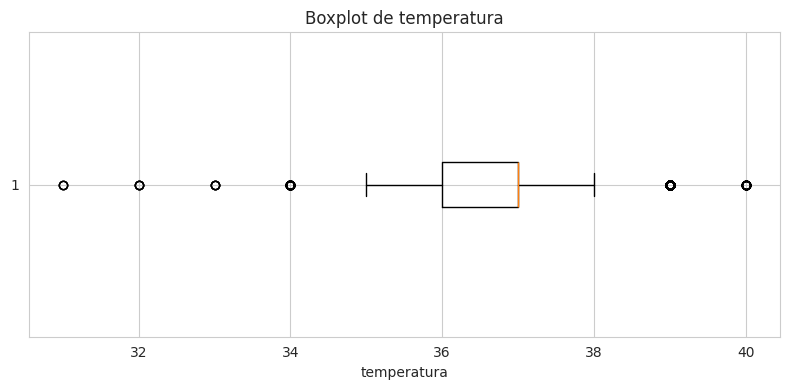

______________________________________________________________________


In [ ]:
print("\n")
print("12. OUTLIERS - MÉTODO IQR")
print("_" * 70)

cols_continuas = [
    c for c in [
        "edad_anios",
        "peso",
        "talla",
        "temperatura"
    ]
    if c in df_clean.columns
]

reporte_outliers = []

for col in cols_continuas:
    datos = df_clean[col].dropna()

    if datos.empty:
        continue

    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    n_outliers = int(
        (
            (datos < limite_inferior)
            | (datos > limite_superior)
        ).sum()
    )

    reporte_outliers.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "n_outliers_iqr": n_outliers,
        "asimetria": datos.skew()
    })

    print(
        f"{col}: {n_outliers} valores fuera "
        f"de 1.5*IQR (se revisan, no se eliminan automáticamente)"
    )

    # Histograma
    plt.figure(figsize=(8, 5))
    plt.hist(datos, bins=30)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de {col}")
    plt.tight_layout()
    plt.savefig(
        CARPETA_SALIDA / f"histograma_{col}.png",
        dpi=150,
        bbox_inches="tight"
    )
    print("_" * 70)
    plt.show()
    print("_" * 70)

    # Boxplot
    plt.figure(figsize=(8, 4))
    plt.boxplot(datos, vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.savefig(
        CARPETA_SALIDA / f"boxplot_{col}.png",
        dpi=150,
        bbox_inches="tight"
    )
    print("_" * 70)
    plt.show()
    print("_" * 70)


pd.DataFrame(reporte_outliers).to_csv(
    CARPETA_SALIDA / "04_reporte_outliers_iqr.csv",
    index=False,
    encoding="utf-8-sig"
)

## 13. RESUMEN FINAL DE CALIDAD

In [ ]:
resumen_final = pd.DataFrame({
    "tipo": df_clean.dtypes.astype(str),
    "nulos": df_clean.isna().sum(),
    "porcentaje_nulos": (
        df_clean.isna().mean() * 100
    ).round(2),
    "valores_unicos": df_clean.nunique(dropna=True)
}).sort_values(
    "porcentaje_nulos",
    ascending=False
)

resumen_final.to_csv(
    CARPETA_SALIDA / "05_resumen_final.csv",
    encoding="utf-8-sig"
)
resumen_final

,tipo,nulos,porcentaje_nulos,valores_unicos
fecha_hos,datetime64[ns],89204,93.59,407
fecha_det,datetime64[ns],89030,93.41,218
neumonia,string,88940,93.32,2
entubado,string,88837,93.21,2
fecha_res_rap1,datetime64[ns],88077,92.41,224
fecha_rap1,datetime64[ns],88075,92.41,225
evolucion,string,67477,70.80,5
ventilacion,string,61797,64.84,3
fecha_res,datetime64[ns],58326,61.20,426
culmina_embarazo,string,58218,61.08,171


## 14. EXPORTACIÓN DEL DATASET LIMPIO

In [ ]:
ruta_limpio = (
    CARPETA_SALIDA
    / "covid_preprocesado_limpio.csv"
)

df_clean.to_csv(
    ruta_limpio,
    index=False,
    encoding="utf-8-sig"
)

print("\nDataset limpio guardado en:")
print(ruta_limpio)


Dataset limpio guardado en:
salidas_preprocesamiento/covid_preprocesado_limpio.csv


## 15. PREPARACIÓN PARA APRENDIZAJE SUPERVISADO

In [ ]:
#
# Esta sección NO entrena modelos.
# Solo deja train/test y el preprocesador listos.

print("\n")
print("15. PREPARACIÓN PARA MACHINE LEARNING")
print("_" * 70)

df_clean[target] = (
        df_clean[target]
        .astype(str)
        .str.strip()
        .str.upper()
        .map({
            "CONFIRMADO": 0,
            "DESCARTADO": 1,
            "SOSPECHOSO": 2,
            "PROBABLE": 3
        })
    )

# 15.1 Variables que no deben usarse como predictoras

cols_no_predictoras = ["id"]

# Posible fuga de información:
# pruebas/resultados utilizados para determinar la clasificación.
prefijos_leakage = (
    "muestra",
    "prueba",
    "resultado",
    "fecha_res"
)

cols_leakage = [
    c for c in df_clean.columns
    if c.lower().startswith(prefijos_leakage)
]

# Eventos potencialmente posteriores al diagnóstico.
cols_post_evento = [
    "fecha_det",
    "fecha_hos",
    "fecha_alt",
    "fecha_def",
    "hora_def",
    "evolucion",
    "ventilacion",
    "entubado"
]

#Talla y Peso (razon 90% de valores nulos no se puede imputar)

cols_tp=['talla','peso']
cols_post_evento = [
    c for c in cols_post_evento
    if c in df_clean.columns
]

cols_excluir = sorted(
    set(
        [target]
        + cols_no_predictoras
        + cols_leakage
        + cols_post_evento
        + cols_tp
    )
)

X = df_clean.drop(
    columns=cols_excluir,
    errors="ignore"
).copy()

y = df_clean[target].copy()

print(f"X antes de retirar fechas crudas: {X.shape}")
print(f"y: {y.shape}")


# 15.2 Retirar fechas crudas
#
# Ya existen 'ano' y 'semana'.
# Las fechas crudas no se entregan directamente al modelo.

cols_datetime_X = X.select_dtypes(
    include=["datetime64[ns]", "datetimetz"]
).columns.tolist()

X = X.drop(columns=cols_datetime_X)

print(
    "Fechas crudas retiradas de X:",
    cols_datetime_X
)

print(f"X final antes del split: {X.shape}")



# Media para la temperatura

X["temperatura"] = X["temperatura"].fillna(X["temperatura"].median())
# 15.4 División train/test

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print(
    f"Train: {X_train.shape}, "
    f"Test: {X_test.shape}"
)


# 15.4 Normalizar binarias a entero




# 15.4 Identificar tipos para el pipeline

cols_numericas_modelo = (
    X_train
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

cols_categoricas_modelo = (
    X_train
    .select_dtypes(
        include=["object", "string", "category"]
    )
    .columns
    .tolist()
)


# 15.5 Normalizar representación de faltantes

for frame in (X_train, X_test):
    # Numéricas -> float / np.nan
    for col in cols_numericas_modelo:
        frame[col] = pd.to_numeric(
            frame[col],
            errors="coerce"
        ).astype(float)

    # Categóricas -> object / np.nan
    for col in cols_categoricas_modelo:
        frame[col] = frame[col].astype(object)
        frame.loc[
            frame[col].isna(),
            col
        ] = np.nan


# 15.6 Pipelines

pipe_num = Pipeline(
    steps=[
        (
            "imputador",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "escalador",
            StandardScaler()
        )
    ]
)

# Compatibilidad con distintas versiones de sklearn.
try:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

pipe_cat = Pipeline(
    steps=[
        (
            "imputador",
            SimpleImputer(
                strategy="constant",
                fill_value="NO REGISTRADO",
                missing_values=np.nan
            )
        ),
        (
            "onehot",
            onehot
        )
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            pipe_num,
            cols_numericas_modelo
        ),
        (
            "cat",
            pipe_cat,
            cols_categoricas_modelo
        )
    ],
    remainder="drop"
)


# 15.7 Ajuste SOLO con entrenamiento

X_train_pre = preprocesador.fit_transform(
    X_train
)

X_test_pre = preprocesador.transform(
    X_test
)

print(
    f"Columnas numéricas: "
    f"{len(cols_numericas_modelo)}"
)

print(
    f"Columnas categóricas: "
    f"{len(cols_categoricas_modelo)}"
)

print(
    f"Dimensión train antes: "
    f"{X_train.shape}"
)

print(
    f"Dimensión train después: "
    f"{X_train_pre.shape}"
)

print(
    f"Dimensión test después: "
    f"{X_test_pre.shape}"
)



15. PREPARACIÓN PARA MACHINE LEARNING
______________________________________________________________________
X antes de retirar fechas crudas: (95311, 120)
y: (95311,)
Fechas crudas retiradas de X: ['fecha_not', 'fecha_ini', 'fecha_ais', 'fecha_mue', 'fecha_rap', 'fecha_rap1']
X final antes del split: (95311, 114)
Train: (76248, 114), Test: (19063, 114)
Columnas numéricas: 66
Columnas categóricas: 48
Dimensión train antes: (76248, 114)
Dimensión train después: (76248, 9335)
Dimensión test después: (19063, 9335)


## 16. GUARDAR ARTEFACTOS PARA EL EQUIPO SUPERVISADO

In [ ]:
joblib.dump(
    preprocesador,
    CARPETA_SALIDA / "preprocesador.joblib"
)

sparse.save_npz(
    CARPETA_SALIDA / "X_train_pre.npz",
    sparse.csr_matrix(X_train_pre)
)

sparse.save_npz(
    CARPETA_SALIDA / "X_test_pre.npz",
    sparse.csr_matrix(X_test_pre)
)

y_train.to_csv(
    CARPETA_SALIDA / "y_train.csv",
    index=False,
    encoding="utf-8-sig"
)

y_test.to_csv(
    CARPETA_SALIDA / "y_test.csv",
    index=False,
    encoding="utf-8-sig"
)

# También guardamos X sin codificar para que el equipo pueda
# modificar selección de variables si lo necesita.
X_train.to_csv(
    CARPETA_SALIDA / "X_train_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

X_test.to_csv(
    CARPETA_SALIDA / "X_test_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

## 17. RESUMEN FINAL

In [ ]:
print("\n")
print("PREPROCESAMIENTO FINALIZADO")
print("_" * 70)

print(f"Filas originales       : {len(df_original):,}")
print(f"Filas dataset limpio   : {len(df_clean):,}")
print(f"Columnas originales    : {df_original.shape[1]:,}")
print(f"Columnas dataset limpio: {df_clean.shape[1]:,}")
print(f"Duplicados encontrados : {n_duplicados}")
print(f"Columnas 100% nulas    : {cols_100_nulos}")
print(f"Nulos eliminados target: {n_target_null}")

print("\nDistribución de clases:")
print(balance_clases)

print("\nIMPORTANTE SOBRE BALANCEO:")
print(
    "No se aplicó SMOTE en el preprocesamiento general. "
    "Si el equipo de aprendizaje supervisado decide utilizar "
    "SMOTE u otra técnica, debe aplicarla únicamente sobre "
    "los datos de entrenamiento."
)

print("\nArchivos generados en:")
print(CARPETA_SALIDA.resolve())



PREPROCESAMIENTO FINALIZADO
______________________________________________________________________
Filas originales       : 95,315
Filas dataset limpio   : 95,311
Columnas originales    : 179
Columnas dataset limpio: 142
Duplicados encontrados : 0
Columnas 100% nulas    : ['otro_hos', 'secuenciamiento']
Nulos eliminados target: 4

Distribución de clases:
               casos  porcentaje
clasificacion                   
CONFIRMADO     51293       53.82
DESCARTADO     34325       36.01
SOSPECHOSO      9611       10.08
PROBABLE          82        0.09

IMPORTANTE SOBRE BALANCEO:
No se aplicó SMOTE en el preprocesamiento general. Si el equipo de aprendizaje supervisado decide utilizar SMOTE u otra técnica, debe aplicarla únicamente sobre los datos de entrenamiento.

Archivos generados en:
/content/salidas_preprocesamiento


# II APRENDIZAJE SUPERVISADO

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report, roc_curve
)
from sklearn.preprocessing import label_binarize
def mostrar_metricas_clasificacion(y_true, y_pred, y_proba=None, promedio="weighted", modelo=''):
    """
    Muestra métricas de evaluación para modelos de clasificación.

    Parámetros:
    -----------
    y_true : array-like
        Valores reales (ground truth).
    y_pred : array-like
        Valores predichos por el modelo.
    y_proba : array-like, opcional
        Probabilidades predichas (necesario para calcular AUC-ROC).
        Para binaria: shape (n_muestras,) o (n_muestras, 2).
        Para multiclase: shape (n_muestras, n_clases).
    promedio : str
        Estrategia de promedio para métricas multiclase:
        "binary", "micro", "macro" o "weighted".
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("=" * 50)
    print("MÉTRICAS DE CLASIFICACIÓN")
    print("=" * 50)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=promedio, zero_division=0)
    rec = recall_score(y_true, y_pred, average=promedio, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=promedio, zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

    auc = None
    if y_proba is not None:
        y_proba = np.array(y_proba)
        try:
            if y_proba.ndim == 1 or y_proba.shape[1] == 2:
                proba = y_proba if y_proba.ndim == 1 else y_proba[:, 1]
                auc = roc_auc_score(y_true, proba)
            else:
                auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average=promedio)
            print(f"AUC-ROC:   {auc:.4f}")
        except Exception as e:
            print(f"AUC-ROC:   No se pudo calcular ({e})")

    print("\nMatriz de confusión:")
    print(confusion_matrix(y_true, y_pred))

    print("\nReporte de clasificación:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc_roc": auc,
        "modelo": modelo
    }
def plot_roc_auc(y_true, y_score, clases=None, title="Curva ROC", mostrar_macro=True):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    plt.figure(figsize=(7, 6))

    # ---------- Caso binario ----------
    if y_score.ndim == 1 or y_score.shape[1] == 2:
        if y_score.ndim == 2:
            y_score = y_score[:, 1]

        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc_final = roc_auc_score(y_true, y_score)
        plt.plot(fpr, tpr, label=f"AUC = {auc_final:.3f}")

    # ---------- Caso multiclase (OvR) ----------
    else:
        n_clases = y_score.shape[1]
        if clases is None:
            clases = np.arange(n_clases)

        y_bin = label_binarize(y_true, classes=clases)

        fprs, tprs = [], []
        for i, clase in enumerate(clases):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
            auc_i = roc_auc_score(y_bin[:, i], y_score[:, i])
            fprs.append(fpr)
            tprs.append(tpr)
            plt.plot(fpr, tpr, alpha=0.8, label=f"Clase {clase} (AUC = {auc_i:.3f})")

        auc_final = roc_auc_score(
            y_true, y_score, multi_class="ovr", average="macro", labels=clases
        )

        if mostrar_macro:
            # Curva macro: se interpolan todas las curvas en un mismo eje FPR
            all_fpr = np.unique(np.concatenate(fprs))
            mean_tpr = np.mean([np.interp(all_fpr, f, t) for f, t in zip(fprs, tprs)], axis=0)
            plt.plot(all_fpr, mean_tpr, color="black", linewidth=2.5,
                     label=f"Macro (AUC = {auc_final:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("Tasa Falso Positivo")
    plt.ylabel("Tasa Verdadero Positivo")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    return auc_final

###CORRELACIÓN

In [ ]:
numericas = df_clean.select_dtypes(include="number").columns

corr = df_clean[numericas].corr()["clasificacion"].sort_values(
    key=abs,
    ascending=False
)
corr

,clasificacion
clasificacion,1.000000
ano,0.133537
id,0.126788
semana,-0.124502
tos,-0.120916
contacto_familiar,-0.110071
fiebre,-0.108220
respiratoria,-0.075656
entorno_familiar,-0.072798
embarazo,0.065235


##ENCODEO

In [ ]:
num_to_drop=['centro_penitenciario','entorno_desconocido',
             'albergue','contacto_trabajo',
             'contacto_desconocido',
             'entorno_salud',
             'contacto_familiar',
             'contacto_salud',
             'convulsion_hos',
             'disnea_hos',
             'coma_hos',
             'auscultacion_hos',
             'radiografia_hos',
             'ecografia_hos',
             'tomografia_hos',
             'rmn_hos',
             'edad']
cat_to_drop=[
    'viajado_14',
    'eess_14',
    'contacto_14',
    'confirmado_14',
    'diresa',
    'mercado_pais'
]

X_train = X_train.drop(columns=num_to_drop+cat_to_drop, errors="ignore")
X_test = X_test.drop(columns=num_to_drop+cat_to_drop, errors="ignore")

cols_cat_texto = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
cardinalidad = X_train[cols_cat_texto].nunique(dropna=False).sort_values(ascending=False)
cols_cat_ohe = cardinalidad[cardinalidad.between(2, 6)].index.tolist()
cols_cat_alta = cardinalidad[cardinalidad > 6].index.tolist()

X_train_pre = X_train.drop(columns=cols_cat_alta, errors="ignore")
X_test_pre = X_test.drop(columns=cols_cat_alta, errors="ignore")

num_cols = X_train_pre.select_dtypes(include=['number']).columns
cat_cols = X_train_pre.select_dtypes(include=['object', 'category']).columns
print("Col Numericas:", num_cols.size , list(num_cols))
print("Col Categóricas:",cat_cols.size , list(cat_cols))

from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cols_cat_ohe:
    le = LabelEncoder()

    # fit solo con train; astype(str) convierte los NaN en la categoría "nan"
    X_train_pre[col] = le.fit_transform(X_train[col].astype(str))
    encoders[col] = le

    # test: se usa el mapa aprendido en train; categorías nuevas -> -1
    mapa = {clase: i for i, clase in enumerate(le.classes_)}
    X_test_pre[col] = X_test_pre[col].astype(str).map(mapa).fillna(-1).astype(int)



Col Numericas: 49 ['ano', 'semana', 'fiebre', 'malestar', 'tos', 'garganta', 'congestion', 'respiratoria', 'diarrea', 'nauseas', 'cefalea', 'irritabilidad', 'muscular', 'abdominal', 'pecho', 'articulaciones', 'anosmia', 'ageusia', 'oido', 'temperatura', 'exudado', 'conjuntival', 'convulsion', 'coma', 'disnea', 'auscultacion', 'rxpulmonar', 'ecografia', 'tomografia', 'rmn', 'embarazo', 'trimestre', 'postparto', 'cardiovascular', 'diabetes', 'hepatica', 'neurologica', 'inmunodeficiencia', 'renal', 'hepatico', 'pulmonar', 'cancer', 'obesidad', 'tbc', 'asma', 'entorno_familiar', 'entorno_trabajo', 'casa_reposo', 'edad_anios']
Col Categóricas: 12 ['institucion', 'punto', 'tipo_edad', 'sexo', 'nacionalidad', 'migrante', 'etnia', 'hospitalizado', 'aislamiento', 'neumonia', 'mercado', 'asintomatico']


##BALANCEO

In [ ]:
from imblearn.over_sampling import SMOTE

print(f"Distribución de clases antes de SMOTE: {y_train.value_counts()}")

smote = SMOTE(random_state=42)
X_train_pre, y_train_pre = smote.fit_resample(X_train_pre, y_train)

print(f"Distribución de clases después de SMOTE: {y_train_pre.value_counts()}")
resultados=[]

Distribución de clases antes de SMOTE: clasificacion
0    41034
1    27460
2     7689
3       65
Name: count, dtype: int64
Distribución de clases después de SMOTE: clasificacion
0    41034
1    41034
2    41034
3    41034
Name: count, dtype: int64


###XGB

MÉTRICAS DE CLASIFICACIÓN
Accuracy:  0.7873
Precision: 0.7964
Recall:    0.7873
F1-score:  0.7913
AUC-ROC:   0.9181

Matriz de confusión:
[[8571 1093  560   35]
 [ 914 5345  597    9]
 [ 423  380 1088   31]
 [   4    0    8    5]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     10259
           1       0.78      0.78      0.78      6865
           2       0.48      0.57      0.52      1922
           3       0.06      0.29      0.10        17

    accuracy                           0.79     19063
   macro avg       0.55      0.62      0.56     19063
weighted avg       0.80      0.79      0.79     19063



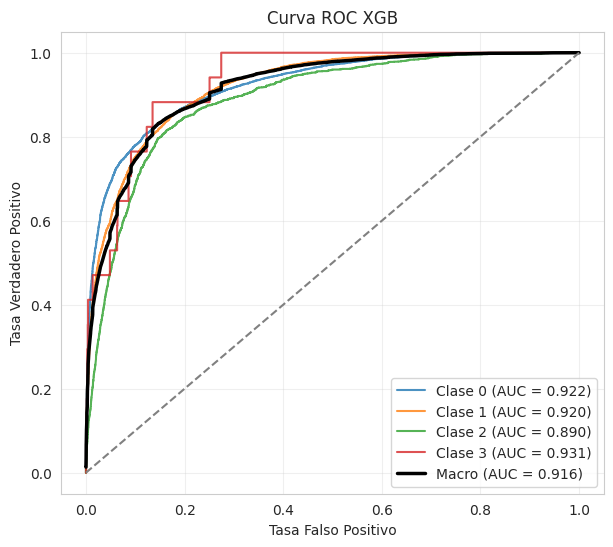

np.float64(0.9158832847855352)

In [ ]:
import xgboost as xgb
modlxgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

modlxgb.fit(
    X_train_pre, y_train_pre,
    eval_set=[(X_test_pre, y_test)],
    verbose=False
)

y_predxgb = modlxgb.predict(X_test_pre)
y_probaxgb = modlxgb.predict_proba(X_test_pre)

# =========================================================
# 8. Evaluar con la función de métricas ya creada
# =========================================================
metricas = mostrar_metricas_clasificacion(y_test, y_predxgb, y_proba=y_probaxgb, modelo="XGB")
resultados.append(metricas)

plot_roc_auc(y_test, y_probaxgb, clases=modlxgb.classes_, title="Curva ROC XGB")

###RANDOM FOREST

MÉTRICAS DE CLASIFICACIÓN
Accuracy:  0.6392
Precision: 0.7359
Recall:    0.6392
F1-score:  0.6812
AUC-ROC:   0.7689

Matriz de confusión:
[[6712 1489  799 1259]
 [1022 4744  574  525]
 [ 300  553  718  351]
 [   1    0    5   11]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.65      0.73     10259
           1       0.70      0.69      0.70      6865
           2       0.34      0.37      0.36      1922
           3       0.01      0.65      0.01        17

    accuracy                           0.64     19063
   macro avg       0.47      0.59      0.45     19063
weighted avg       0.74      0.64      0.68     19063



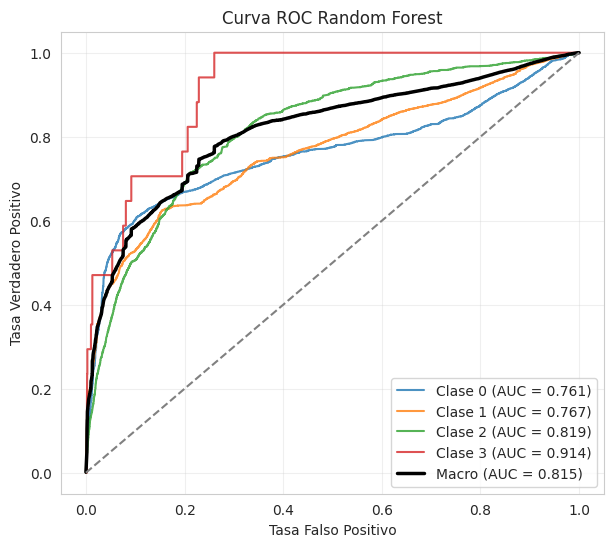

np.float64(0.8150590640087614)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

forest.fit(X_train_pre, y_train_pre)

y_pred = forest.predict(X_test_pre)
y_probs = forest.predict_proba(X_test_pre)

resultados.append(mostrar_metricas_clasificacion(y_test, y_pred, y_probs, modelo="Random Forest"))
plot_roc_auc(y_test, y_probs, clases=forest.classes_, title="Curva ROC Random Forest")

###K-NEIGHBORS

MÉTRICAS DE CLASIFICACIÓN
Accuracy:  0.6603
Precision: 0.7290
Recall:    0.6603
F1-score:  0.6830
AUC-ROC:   0.8192

Matriz de confusión:
[[6726 1807 1589  137]
 [ 904 4765 1149   47]
 [ 280  493 1091   58]
 [   2    2    8    5]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.66      0.74     10259
           1       0.67      0.69      0.68      6865
           2       0.28      0.57      0.38      1922
           3       0.02      0.29      0.04        17

    accuracy                           0.66     19063
   macro avg       0.46      0.55      0.46     19063
weighted avg       0.73      0.66      0.68     19063



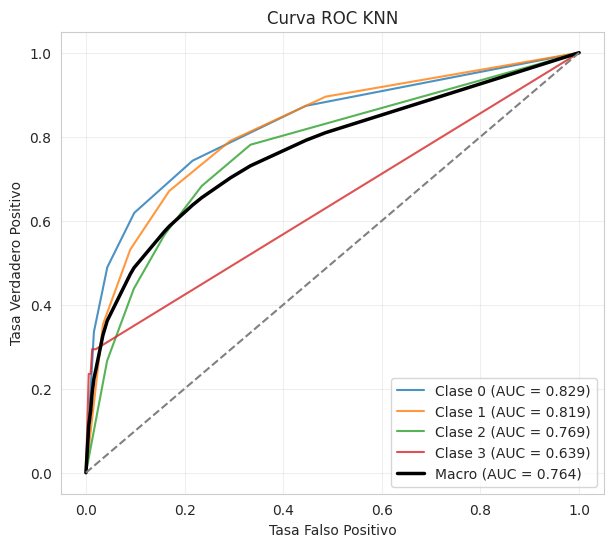

np.float64(0.76389613594476)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_pre, y_train_pre)

y_pred = knn.predict(X_test_pre)
y_probs = knn.predict_proba(X_test_pre)

resultados.append(mostrar_metricas_clasificacion(y_test, y_pred, y_probs, modelo="K-Nearest Neighbors"))
plot_roc_auc(y_test, y_probs,clases=knn.classes_,title="Curva ROC KNN")

###ARBOL DE DECISIÓN

MÉTRICAS DE CLASIFICACIÓN
Accuracy:  0.6514
Precision: 0.7443
Recall:    0.6514
F1-score:  0.6832
AUC-ROC:   0.8340

Matriz de confusión:
[[6544 1747 1542  426]
 [ 787 4790 1050  238]
 [ 132  563 1076  151]
 [   1    1    7    8]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.64      0.74     10259
           1       0.67      0.70      0.69      6865
           2       0.29      0.56      0.38      1922
           3       0.01      0.47      0.02        17

    accuracy                           0.65     19063
   macro avg       0.46      0.59      0.46     19063
weighted avg       0.74      0.65      0.68     19063



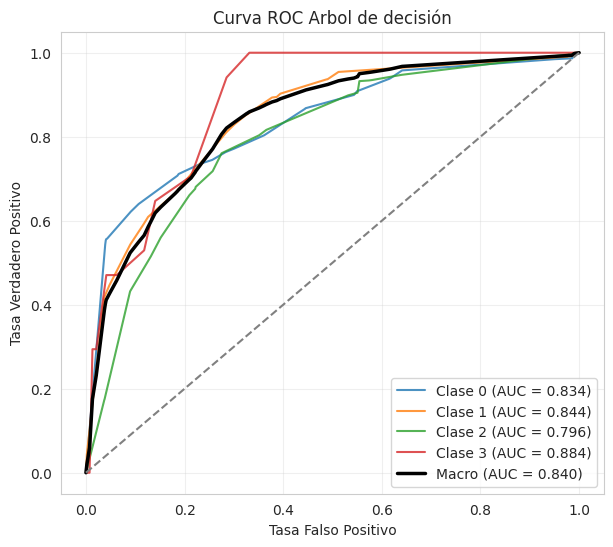

np.float64(0.8395839797127104)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

arbol.fit(X_train_pre, y_train_pre)

y_pred = arbol.predict(X_test_pre)
y_probs = arbol.predict_proba(X_test_pre)

resultados.append(mostrar_metricas_clasificacion(y_test, y_pred, y_probs, modelo="Arbol de decisión"))

plot_roc_auc(y_test, y_probs, clases=arbol.classes_, title="Curva ROC Arbol de decisión")

##RESULTADOS

In [ ]:
pd.DataFrame(resultados)

,accuracy,precision,recall,f1,auc_roc,modelo
0,0.787337,0.796418,0.787337,0.791339,0.918129,XGB
1,0.639196,0.735851,0.639196,0.681242,0.768941,Random Forest
2,0.660284,0.728995,0.660284,0.682973,0.819222,K-Nearest Neighbors
3,0.651419,0.744280,0.651419,0.683229,0.833997,Arbol de decisión


#III APRENDIZAJE NO SUPERVISADO

##Selección de variables


In [ ]:
df = df.head(5000).copy()

In [ ]:
symptom_cols = ['fiebre','tos','garganta','congestion','respiratoria','diarrea',
                 'nauseas','cefalea','muscular','abdominal','disnea']

comorb_cols = ['diabetes','cardiovascular','obesidad','asma','renal','neurologica','tbc']

work = df[['id','edad','sexo','clasificacion','hospitalizado','evolucion',
           'provincia_infeccion','ocupacion','resultado'] + symptom_cols + comorb_cols].copy()

work

,id,edad,sexo,clasificacion,hospitalizado,evolucion,provincia_infeccion,ocupacion,resultado,fiebre,tos,garganta,congestion,respiratoria,diarrea,nauseas,cefalea,muscular,abdominal,disnea,diabetes,cardiovascular,obesidad,asma,renal,neurologica,tbc
0,542,31,MASCULINO,DESCARTADO,NO,DESCONOCIDO,LIMA,TRABAJADOR DE SALUD,NEGATIVO,0,0,1,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0
1,1234,53,MASCULINO,DESCARTADO,DESCONOCIDO,NaN,NaN,OTROS,NaN,1,0,1,0,0,0,0,1,1,1,0,0,0,NaN,NaN,0,0,NaN
2,1258,47,FEMENINO,DESCARTADO,NO,NaN,NaN,OTROS,NaN,1,0,0,0,0,0,0,1,0,0,0,0,0,NaN,NaN,0,0,NaN
3,1266,76,FEMENINO,DESCARTADO,NO,NaN,NaN,OTROS,NaN,1,1,0,0,0,0,0,1,1,0,0,0,0,NaN,NaN,0,0,NaN
4,1292,49,MASCULINO,CONFIRMADO,NO,NaN,NaN,OTROS,NEGATIVO,0,1,1,0,0,1,0,1,0,0,0,0,0,0.0,0.0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,379150,43,MASCULINO,CONFIRMADO,NO,RECUPERADO,NaN,OTROS,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,NaN
4996,379165,8,FEMENINO,DESCARTADO,NO,NaN,NaN,ESTUDIANTE,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,NaN
4997,379187,58,MASCULINO,CONFIRMADO,SI,ESTACIONARIA,NaN,OTROS,POSITIVO,0,1,1,1,0,0,0,1,1,0,0,1,1,0.0,0.0,0,0,0.0
4998,379194,30,MASCULINO,DESCARTADO,NO,NaN,NaN,OTROS,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,NaN


In [ ]:
work[symptom_cols] = work[symptom_cols].fillna(0)
work[comorb_cols] = work[comorb_cols].fillna(0)

work['n_sintomas'] = work[symptom_cols].sum(axis=1)
work['n_comorbilidades'] = work[comorb_cols].sum(axis=1)
work['sexo_bin'] = (work['sexo'] == 'MASCULINO').astype(int)

feature_cols = ['edad', 'sexo_bin', 'n_sintomas', 'n_comorbilidades'] + symptom_cols + comorb_cols
X = work[feature_cols].astype(float).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=feature_cols, index=work['id']).round(2)


,edad,sexo_bin,n_sintomas,n_comorbilidades,fiebre,tos,garganta,congestion,respiratoria,diarrea,nauseas,cefalea,muscular,abdominal,disnea,diabetes,cardiovascular,obesidad,asma,renal,neurologica,tbc
id,,,,,,,,,,,,,,,,,,,,,,
542,-0.47,1.10,0.15,-0.16,-0.33,-0.42,2.33,-0.29,-0.25,-0.17,-0.16,-0.39,-0.19,-0.11,-0.1,-0.09,-0.13,-0.03,-0.01,-0.05,-0.04,0.0
1234,0.93,1.10,2.90,-0.16,3.05,-0.42,2.33,-0.29,-0.25,-0.17,-0.16,2.58,5.19,8.92,-0.1,-0.09,-0.13,-0.03,-0.01,-0.05,-0.04,0.0
1258,0.55,-0.91,0.84,-0.16,3.05,-0.42,-0.43,-0.29,-0.25,-0.17,-0.16,2.58,-0.19,-0.11,-0.1,-0.09,-0.13,-0.03,-0.01,-0.05,-0.04,0.0
1266,2.40,-0.91,2.22,-0.16,3.05,2.40,-0.43,-0.29,-0.25,-0.17,-0.16,2.58,5.19,-0.11,-0.1,-0.09,-0.13,-0.03,-0.01,-0.05,-0.04,0.0
1292,0.68,1.10,2.22,-0.16,-0.33,2.40,2.33,-0.29,-0.25,5.75,-0.16,2.58,-0.19,-0.11,-0.1,-0.09,-0.13,-0.03,-0.01,-0.05,-0.04,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379150,0.30,1.10,-0.54,-0.16,-0.33,-0.42,-0.43,-0.29,-0.25,-0.17,-0.16,-0.39,-0.19,-0.11,-0.1,-0.09,-0.13,-0.03,-0.01,-0.05,-0.04,0.0
379165,-1.93,-0.91,-0.54,-0.16,-0.33,-0.42,-0.43,-0.29,-0.25,-0.17,-0.16,-0.39,-0.19,-0.11,-0.1,-0.09,-0.13,-0.03,-0.01,-0.05,-0.04,0.0
379187,1.25,1.10,2.90,10.55,-0.33,2.40,2.33,3.40,-0.25,-0.17,-0.16,2.58,5.19,-0.11,-0.1,11.58,7.65,-0.03,-0.01,-0.05,-0.04,0.0


## Reducción de dimensionalidad con PCA

In [ ]:
pca = PCA(n_components=min(5, X_scaled.shape[0]-1))
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

print("Varianza explicada por componente:", np.round(var_exp, 3))
print("Varianza acumulada (2 componentes):", round(var_exp[:2].sum(), 3))


Varianza explicada por componente: [0.2   0.103 0.058 0.055 0.049]
Varianza acumulada (2 componentes): 0.303


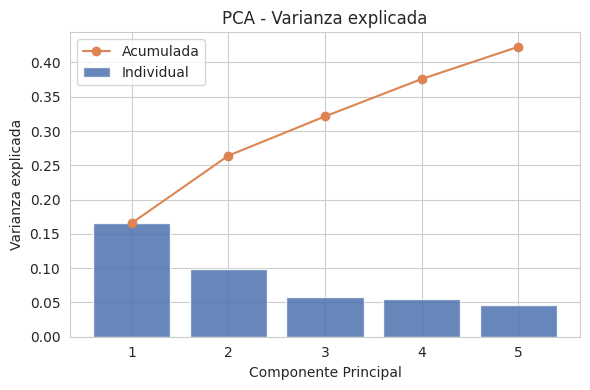

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(range(1, len(var_exp)+1), var_exp, color='#4C72B0', alpha=0.85, label='Individual')
ax.plot(range(1, len(var_exp)+1), np.cumsum(var_exp), color='#DD8452', marker='o', label='Acumulada')
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Varianza explicada')
ax.set_title('PCA - Varianza explicada')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Cargas (loadings) de las 2 primeras componentes: que variables pesan mas en cada eje
loadings = pd.DataFrame(pca.components_[:2].T, index=feature_cols, columns=['PC1','PC2'])
loadings.round(2).sort_values('PC1', ascending=False)


,PC1,PC2
n_sintomas,0.52,-0.09
tos,0.34,-0.06
fiebre,0.32,-0.07
garganta,0.32,-0.09
cefalea,0.29,-0.06
congestion,0.26,-0.09
respiratoria,0.24,0.04
diarrea,0.22,-0.06
muscular,0.22,-0.03
nauseas,0.21,-0.04


##Selección del número óptimo de clusters

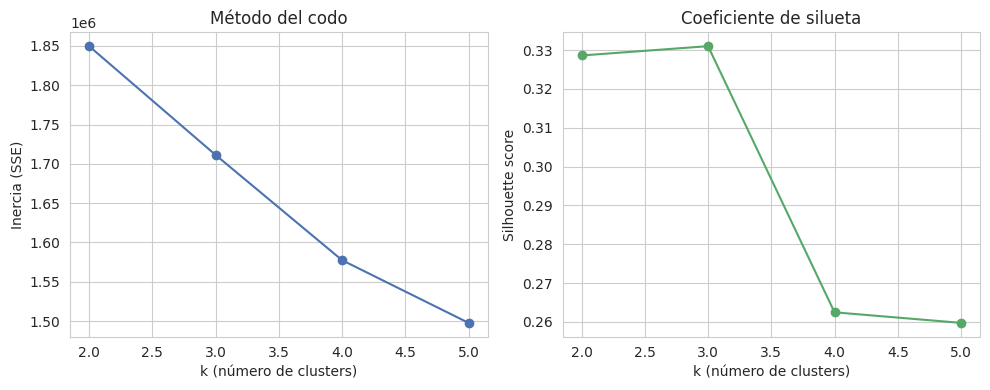

Mejor k según silueta: 3 | scores: [0.329 0.331 0.262 0.26 ]


In [ ]:
inertias, sil_scores = [], []
K_range = range(2, 6)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(list(K_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('k (número de clusters)')
axes[0].set_ylabel('Inercia (SSE)')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#55A868')
axes[1].set_title('Coeficiente de silueta')
axes[1].set_xlabel('k (número de clusters)')
axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print("Mejor k según silueta:", best_k, "| scores:", np.round(sil_scores, 3))


##K-Means

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
work['cluster_kmeans'] = kmeans.fit_predict(X_scaled)
work[['id','edad','sexo','clasificacion','n_sintomas','n_comorbilidades','cluster_kmeans']]


,id,edad,sexo,clasificacion,n_sintomas,n_comorbilidades,cluster_kmeans
0,542,31,MASCULINO,DESCARTADO,1,0.0,1
1,1234,53,MASCULINO,DESCARTADO,5,0.0,0
2,1258,47,FEMENINO,DESCARTADO,2,0.0,0
3,1266,76,FEMENINO,DESCARTADO,4,0.0,0
4,1292,49,MASCULINO,CONFIRMADO,4,0.0,0
...,...,...,...,...,...,...,...
4995,379150,43,MASCULINO,CONFIRMADO,0,0.0,1
4996,379165,8,FEMENINO,DESCARTADO,0,0.0,1
4997,379187,58,MASCULINO,CONFIRMADO,5,2.0,2
4998,379194,30,MASCULINO,DESCARTADO,0,0.0,1


In [ ]:
profile = work.groupby('cluster_kmeans')[['edad','n_sintomas','n_comorbilidades']].mean().round(2)
profile['n_casos'] = work.groupby('cluster_kmeans').size()
profile


,edad,n_sintomas,n_comorbilidades,n_casos
cluster_kmeans,,,,
0,40.62,3.63,0.00,709
1,37.44,0.25,0.00,4152
2,52.60,2.01,1.09,139


##Visualización final en el plano PCA

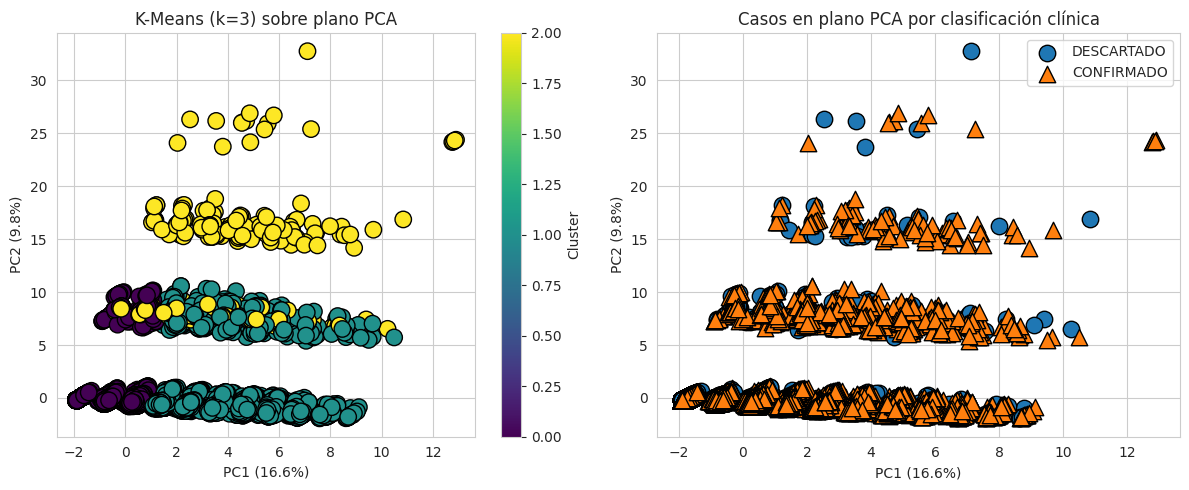

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sc0 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=work['cluster_kmeans'], cmap='viridis', s=140, edgecolor='k')

axes[0].set_title(f'K-Means (k={best_k}) sobre plano PCA')
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
plt.colorbar(sc0, ax=axes[0], label='Cluster')

markers = {'DESCARTADO': 'o', 'CONFIRMADO': '^'}
for clas, mk in markers.items():
    mask = (work['clasificacion'] == clas).values
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1], marker=mk, s=140, label=clas, edgecolor='k')

axes[1].set_title('Casos en plano PCA por clasificación clínica')
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
axes[1].legend()

plt.tight_layout()
plt.show()

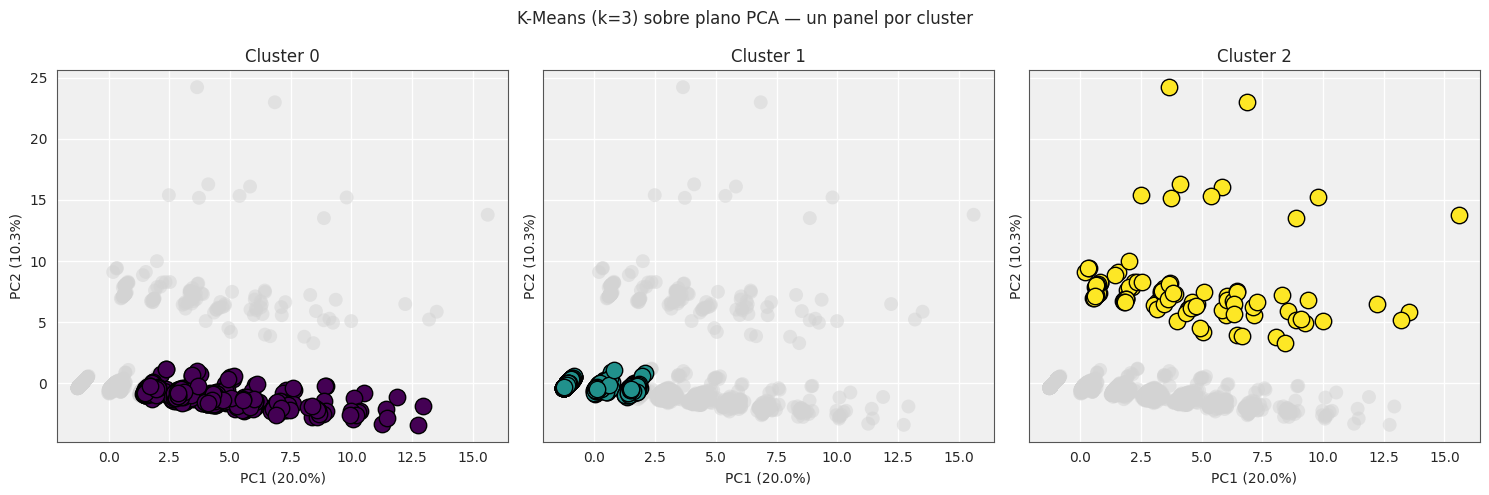

In [ ]:
n_clusters = best_k  # se ajusta solo si best_k es 3, 4, etc.

fig, axes = plt.subplots(1, n_clusters, figsize=(5*n_clusters, 5), sharex=True, sharey=True)

cmap = plt.get_cmap('viridis', n_clusters)

for i, ax in enumerate(axes):
    # fondo: todos los casos en gris claro, para dar contexto
    ax.scatter(X_pca[:,0], X_pca[:,1], c='lightgray', s=100, edgecolor='none', alpha=0.5)

    # resalta solo los casos del cluster i
    mask = (work['cluster_kmeans'] == i).values
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=[cmap(i)], s=140, edgecolor='k',
               label=f'Cluster {i}')

    ax.set_title(f'Cluster {i}')
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')

plt.suptitle(f'K-Means (k={best_k}) sobre plano PCA — un panel por cluster')
plt.tight_layout()
plt.show()

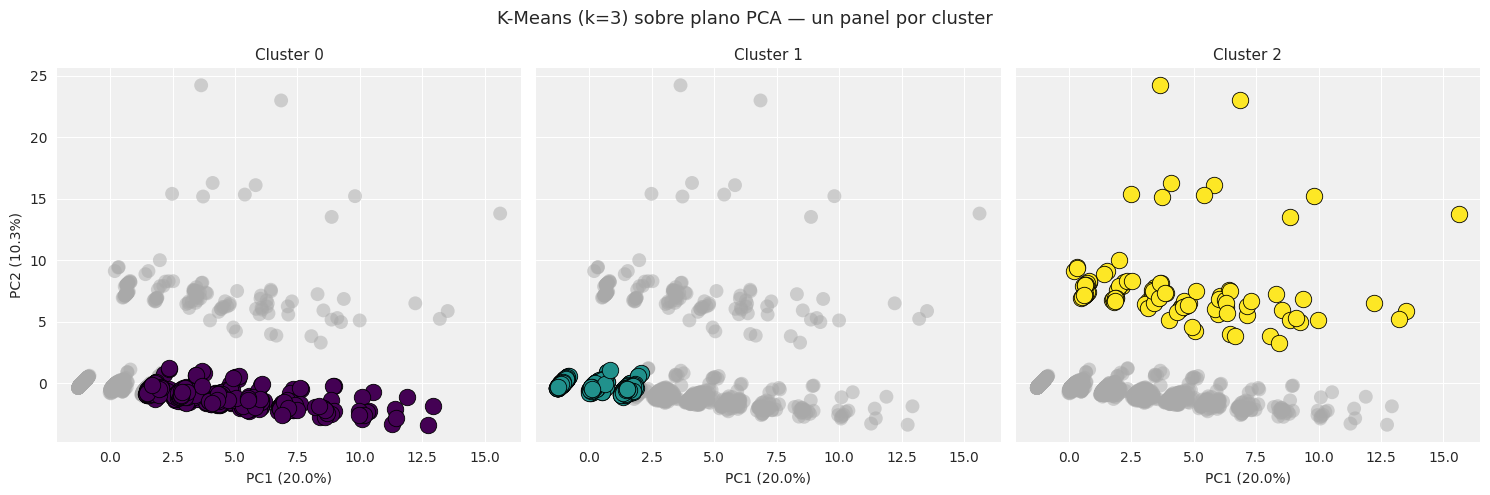

In [ ]:
# --- Estilo general ---
plt.rcParams['axes.facecolor'] = '#f0f0f0'   # fondo gris claro de los ejes
plt.rcParams['axes.edgecolor'] = '#555555'
plt.rcParams['grid.color'] = 'white'          # malla blanca sobre fondo gris (estilo tipo seaborn)
plt.rcParams['grid.linewidth'] = 1.0

n_clusters = best_k

fig, axes = plt.subplots(1, n_clusters, figsize=(5*n_clusters, 5), sharex=True, sharey=True)

cmap = plt.get_cmap('viridis', n_clusters)

for i, ax in enumerate(axes):
    ax.set_facecolor('#f0f0f0')
    ax.grid(True, which='major', linestyle='-', linewidth=0.8, color='white', zorder=0)
    ax.set_axisbelow(True)  # la malla queda detrás de los puntos

    # fondo: todos los casos en gris, para dar contexto
    ax.scatter(X_pca[:,0], X_pca[:,1], c='darkgray', s=100, edgecolor='none', alpha=0.5, zorder=1)

    # resalta solo los casos del cluster i
    mask = (work['cluster_kmeans'] == i).values
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=[cmap(i)], s=140, edgecolor='k',
               linewidth=0.6, zorder=2, label=f'Cluster {i}')

    ax.set_title(f'Cluster {i}', fontsize=11)
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
    if i == 0:
        ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')

    for spine in ax.spines.values():
        spine.set_visible(False)  # sin bordes duros, look más limpio

plt.suptitle(f'K-Means (k={best_k}) sobre plano PCA — un panel por cluster', fontsize=13)
plt.tight_layout()
plt.show()

##Clustering jerárquico (aglomerativo, enlace de Ward)

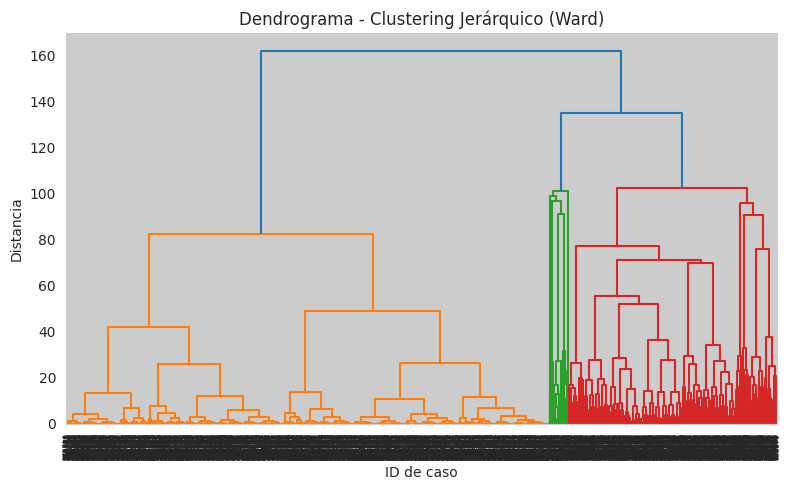

In [ ]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(8,5))
dendrogram(Z, labels=work['id'].astype(str).values, ax=ax, color_threshold=0.7*max(Z[:,2]))
ax.set_title('Dendrograma - Clustering Jerárquico (Ward)')
ax.set_xlabel('ID de caso')
ax.set_ylabel('Distancia')
plt.tight_layout()
plt.show()


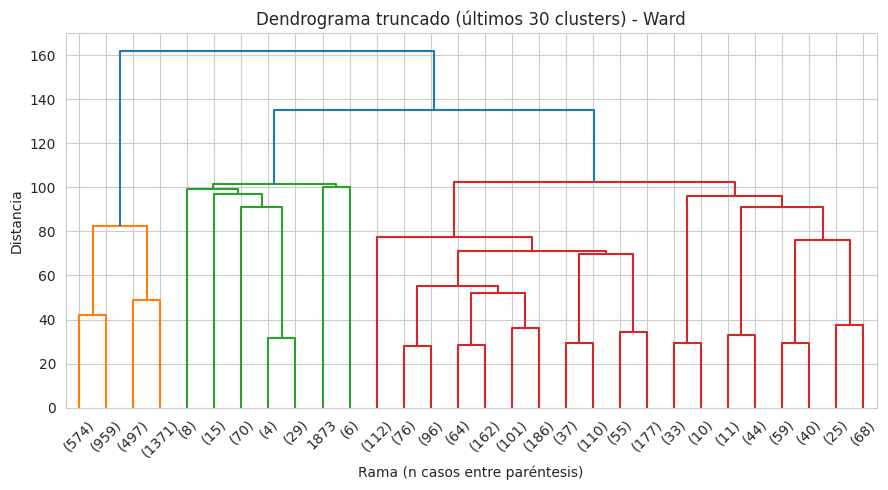

In [ ]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(9,5))
dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True,
           color_threshold=0.7*max(Z[:,2]), ax=ax)
ax.set_title('Dendrograma truncado (últimos 30 clusters) - Ward')
ax.set_xlabel('Rama (n casos entre paréntesis)')
ax.set_ylabel('Distancia')
plt.tight_layout()
plt.show()

##DBSCAN (detección de valores atípicos)

In [ ]:
dbscan = DBSCAN(eps=2.2, min_samples=2)
work['cluster_dbscan'] = dbscan.fit_predict(X_scaled)
work[['id','sexo','ocupacion','n_sintomas','cluster_dbscan']]


,id,sexo,ocupacion,n_sintomas,cluster_dbscan
0,542,MASCULINO,TRABAJADOR DE SALUD,1,0
1,1234,MASCULINO,OTROS,5,-1
2,1258,FEMENINO,OTROS,2,1
3,1266,FEMENINO,OTROS,4,2
4,1292,MASCULINO,OTROS,4,3
...,...,...,...,...,...
4995,379150,MASCULINO,OTROS,0,17
4996,379165,FEMENINO,ESTUDIANTE,0,17
4997,379187,MASCULINO,OTROS,5,-1
4998,379194,MASCULINO,OTROS,0,17


In [ ]:
print(work['cluster_dbscan'].unique())

[  0  -1   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134]
